In [47]:
import pandas as pd

In [48]:
import numpy as np

In [49]:
df=pd.read_csv("swiggy_file.csv")
df.head()

,Restaurant Name,Cuisine,Rating,Number of Ratings,Average Price,Number of Offers,Offer Name,Area,Pure Veg,Location
0,La Pino'Z Pizza,"Pizzas, Pastas",4.0,10+ ratings,₹250 for two,2,FLAT DEAL\nFLAT ₹125 OFF\nUSE FLAT125ABOVE ₹69...,LALA LAJPAT RAI MARKET,No,Abohar
1,The Second Wife,"Indian, North Indian",3.6,50+ ratings,₹250 for two,2,"30% OFF UPTO ₹75\nUSE TRYNEWABOVE ₹149, FLAT ₹...",Central Abohar,No,Abohar
2,Tasty Bites,"Italian, Beverages",3.8,10+ ratings,₹200 for two,1,FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500,Central Abohar,Yes,Abohar
3,Food Studio,"Pizzas, Burgers",3.5,8 ratings,₹49 for two,5,"50% OFF UPTO ₹100\nUSE TRYNEWABOVE ₹129, FLAT ...",Central Abohar,Yes,Abohar
4,Roll Express,"Fast Food, Snacks",4.3,100+ ratings,₹200 for two,2,DEAL OF DAY\n10% OFF UPTO ₹40\nUSE STEALDEALAB...,Circular Road,No,Abohar


In [50]:
print("Shape:", df.shape)


Shape: (140657, 10)


In [51]:
print("\nColumn names:", df.columns.tolist())



Column names: ['Restaurant Name', 'Cuisine', 'Rating', 'Number of Ratings', 'Average Price', 'Number of Offers', 'Offer Name', 'Area', 'Pure Veg', 'Location']


In [52]:
print("\nData types:\n", df.dtypes)


Data types:
 Restaurant Name      object
Cuisine              object
Rating               object
Number of Ratings    object
Average Price        object
Number of Offers      int64
Offer Name           object
Area                 object
Pure Veg             object
Location             object
dtype: object


In [53]:
print("\nNull counts:\n", df.isnull().sum())


Null counts:
 Restaurant Name          0
Cuisine                 27
Rating                   0
Number of Ratings    14542
Average Price            0
Number of Offers         0
Offer Name            1808
Area                     2
Pure Veg                 0
Location                 0
dtype: int64


In [54]:
print(df.head(3).to_string())
print("---")
print(df['Rating'].value_counts().head(10))
print("---")
print(df['Number of Ratings'].value_counts().head(10))
print("---")
print(df['Average Price'].value_counts().head(10))
print("---")
print(df['Pure Veg'].value_counts())

   Restaurant Name               Cuisine Rating Number of Ratings Average Price  Number of Offers                                                                             Offer Name                    Area Pure Veg Location
0  La Pino'Z Pizza        Pizzas, Pastas    4.0       10+ ratings  ₹250 for two                 2  FLAT DEAL\nFLAT ₹125 OFF\nUSE FLAT125ABOVE ₹699, FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500  LALA LAJPAT RAI MARKET       No   Abohar
1  The Second Wife  Indian, North Indian    3.6       50+ ratings  ₹250 for two                 2           30% OFF UPTO ₹75\nUSE TRYNEWABOVE ₹149, FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500          Central Abohar       No   Abohar
2      Tasty Bites    Italian, Beverages    3.8       10+ ratings  ₹200 for two                 1                                                   FLAT ₹120 OFF\nUSE AXIS120ABOVE ₹500          Central Abohar      Yes   Abohar
---
Rating
--     19177
NEW    14542
4.3    13351
4.2    12717
4.1    10719
4.4     8945
4.0

In [55]:
#Second Section:DATA CLEANING & FEATURE ENGINEERING  


In [56]:
print(f"Shape before cleaning: {df.shape}")


Shape before cleaning: (140657, 10)


In [57]:
df["Rating"]=df["Rating"].replace({'--':np.nan,'NEW':np.nan})
df["Rating"]=pd.to_numeric(df["Rating"],errors='coerce')
print(f"Ratings cleaned. Nulls now: {df['Rating'].isnull().sum()}")

Ratings cleaned. Nulls now: 33719


In [58]:
def parse_num_ratings(val):
    val = str(val).strip().upper()
    if 'TOO FEW' in val or val == 'NAN':
        return np.nan
    val = val.replace('+ RATINGS', '').replace(' RATINGS', '').strip()
    if 'K' in val:
        return float(val.replace('K', '')) * 1000
    try:
        return float(val.replace('+', ''))
    except:
        return np.nan

df['Number of Ratings'] = df['Number of Ratings'].apply(parse_num_ratings)
print(f"Number of Ratings cleaned. Nulls now: {df['Number of Ratings'].isnull().sum()}")



Number of Ratings cleaned. Nulls now: 33719


In [59]:
df['Average Price'] = df['Average Price'].str.replace('₹', '', regex=False)
df['Average Price'] = df['Average Price'].str.replace('for two', '', regex=False)
df['Average Price'] = df['Average Price'].str.replace(',', '', regex=False).str.strip()
df['Average Price'] = pd.to_numeric(df['Average Price'], errors='coerce')

print(f"Average Price cleaned. Nulls now: {df['Average Price'].isnull().sum()}")

Average Price cleaned. Nulls now: 0


In [60]:
df['Offer Name'] = df['Offer Name'].str.replace('\n', ' | ', regex=False)
df['Offer Name'] = df['Offer Name'].fillna('No Offer')

print(f"Offer Name cleaned.")

Offer Name cleaned.


In [61]:
df['Cuisine'] = df['Cuisine'].fillna('Unknown')

In [62]:
df['Area'] = df['Area'].fillna('Unknown')

In [63]:
df['Pure Veg'] = df['Pure Veg'].str.strip().str.capitalize()



In [64]:
#Feature Engineering 
df['Price Segment']=pd.cut(df['Average Price'],bins=[0,200,400,700,99999],labels=['Budget','Mid-Range','Premium','Luxury'])

In [65]:
# Has offer flag
df['Has Offer'] = df['Number of Offers'] > 0

In [66]:
df['Offer Tier'] = pd.cut(df['Number of Offers'],
    bins=[-1, 0, 1, 3, 100],
    labels=['No Offer', 'Light', 'Moderate', 'Heavy'])

In [67]:
# Engagement rate — how many ratings per price unit
df['Engagement Rate'] = df['Number of Ratings'] / (df['Average Price'] + 1)

In [68]:
# Success Score — composite metric (the unique angle)
# Weighted: 50% rating + 30% engagement + 20% value-for-money
df['Success Score'] = (
    (df['Rating'] / 5) * 0.5 +
    (df['Number of Ratings'] / df['Number of Ratings'].max()) * 0.3 +
    (1 - df['Average Price'] / df['Average Price'].max()) * 0.2
) * 100

In [69]:
print(f"\nShape after cleaning: {df.shape}")
print(f"\nNull counts after cleaning:\n{df.isnull().sum()}")
print(f"\nNew columns added: Price Segment, Has Offer, Offer Tier, Engagement Rate, Success Score")
print(f"\nSample of cleaned data:")
df.head(3)


Shape after cleaning: (140657, 15)

Null counts after cleaning:
Restaurant Name          0
Cuisine                  0
Rating               33719
Number of Ratings    33719
Average Price            0
Number of Offers         0
Offer Name               0
Area                     0
Pure Veg                 0
Location                 0
Price Segment            1
Has Offer                0
Offer Tier               0
Engagement Rate      33719
Success Score        33719
dtype: int64

New columns added: Price Segment, Has Offer, Offer Tier, Engagement Rate, Success Score

Sample of cleaned data:


,Restaurant Name,Cuisine,Rating,Number of Ratings,Average Price,Number of Offers,Offer Name,Area,Pure Veg,Location,Price Segment,Has Offer,Offer Tier,Engagement Rate,Success Score
0,La Pino'Z Pizza,"Pizzas, Pastas",4.0,10.0,250,2,FLAT DEAL | FLAT ₹125 OFF | USE FLAT125ABOVE ₹...,LALA LAJPAT RAI MARKET,No,Abohar,Mid-Range,True,Moderate,0.039841,60.004905
1,The Second Wife,"Indian, North Indian",3.6,50.0,250,2,"30% OFF UPTO ₹75 | USE TRYNEWABOVE ₹149, FLAT ...",Central Abohar,No,Abohar,Mid-Range,True,Moderate,0.199203,56.124905
2,Tasty Bites,"Italian, Beverages",3.8,10.0,200,1,FLAT ₹120 OFF | USE AXIS120ABOVE ₹500,Central Abohar,Yes,Abohar,Budget,True,Light,0.049751,58.009924


In [70]:
# Fix the 1 null in Price Segment
df['Price Segment'] = df['Price Segment'].cat.add_categories('Unknown')
df['Price Segment'] = df['Price Segment'].fillna('Unknown')

# Verify
print(df['Price Segment'].value_counts())
print(f"\nTotal nulls remaining: {df.isnull().sum().sum()}")

Price Segment
Budget       65016
Mid-Range    63940
Premium       9833
Luxury        1867
Unknown          1
Name: count, dtype: int64

Total nulls remaining: 134876


In [71]:
# SECTION 3 — EDA & 6 BUSINESS QUESTIONS
# We'll use this filtered dataframe for analyses that need ratings
df_rated = df[df['Rating'].notna()].copy()

print(f"Total restaurants: {len(df)}")
print(f"Rated restaurants: {len(df_rated)}")
print(f"Unrated restaurants: {len(df) - len(df_rated)}")

Total restaurants: 140657
Rated restaurants: 106938
Unrated restaurants: 33719


In [72]:
# ─────────────────────────────────────────
# Q1 — WHERE SHOULD A RESTAURANT LAUNCH?
# Find cities with high demand but low quality
# ─────────────────────────────────────────

import matplotlib.pyplot as plt
import seaborn as sns

# Top 15 cities by restaurant count
city_overview = df.groupby('Location').agg(
    Total_Restaurants=('Restaurant Name', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Engagement=('Number of Ratings', 'mean')
).round(2).reset_index()

# Filter cities with decent presence (min 200 restaurants)
city_overview = city_overview[city_overview['Total_Restaurants'] >= 200]

# Sort by total restaurants
city_overview = city_overview.sort_values('Total_Restaurants', ascending=False).head(15)

print(city_overview.to_string())

           Location  Total_Restaurants  Avg_Rating  Avg_Engagement
268          Kanpur               2405        4.05          611.75
265     Kanchrapara               2037        3.96          674.01
378          Nagpur               1998        4.06          625.51
230       Hyderabad               1998        3.98          998.66
561        Vadodara               1998        4.15          522.17
233          Indore               1998        3.96          520.01
112     Central-Goa               1998        4.15          360.20
321         Lucknow               1996        4.04          829.72
240          Jaipur               1990        4.02          497.01
299         Kolkata               1974        3.96          684.32
89      Bhubaneswar               1906        4.12          747.32
365          Mumbai               1893        4.12          783.91
163  Doddaballapura               1893        3.99          594.22
132      Coimbatore               1889        4.18          87

In [73]:
import os

# Create outputs folder in the same directory as your notebook
os.makedirs('outputs', exist_ok=True)
print("Outputs folder ready!")

Outputs folder ready!


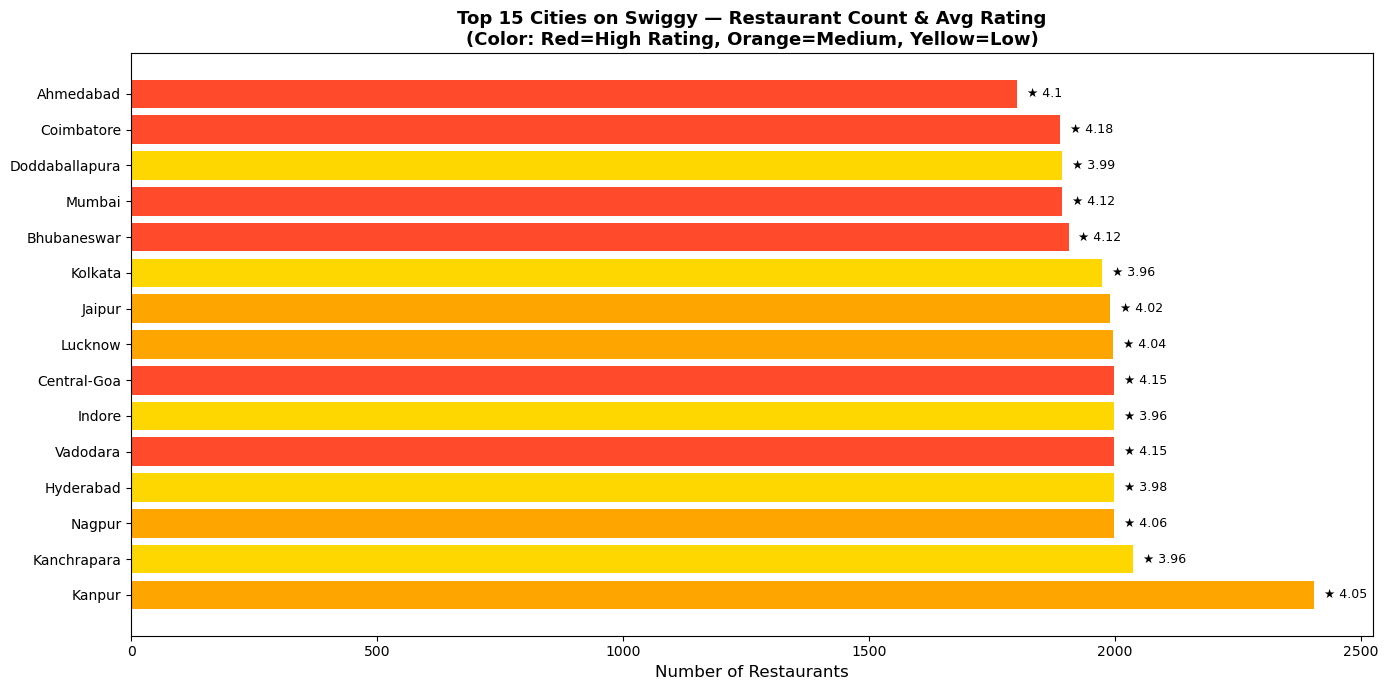

Chart saved!


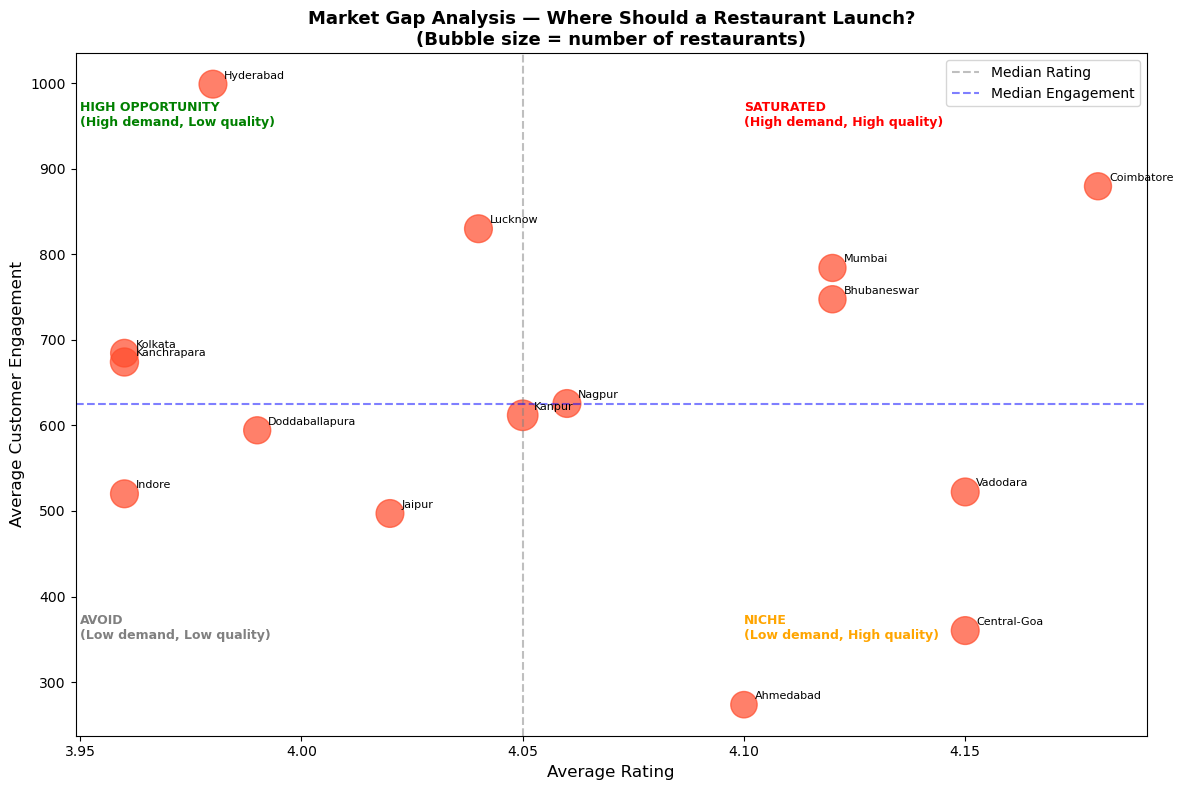

Market gap chart saved!


In [74]:
# ─────────────────────────────────────────
# Q1 — CHART 1: Top 15 Cities by Restaurant Count
# ─────────────────────────────────────────

plt.figure(figsize=(14, 7))
colors = ['#FF4B2B' if x >= 4.10 else '#FFA500' if x >= 4.0 else '#FFD700' 
          for x in city_overview['Avg_Rating']]

bars = plt.barh(city_overview['Location'], 
                city_overview['Total_Restaurants'],
                color=colors)

# Add value labels on bars
for bar, rating in zip(bars, city_overview['Avg_Rating']):
    plt.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             f'★ {rating}', va='center', fontsize=9)

plt.xlabel('Number of Restaurants', fontsize=12)
plt.title('Top 15 Cities on Swiggy — Restaurant Count & Avg Rating\n(Color: Red=High Rating, Orange=Medium, Yellow=Low)', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Q1_city_restaurant_count.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

# ─────────────────────────────────────────
# Q1 — CHART 2: Market Gap — Engagement vs Rating
# This is your SHOWSTOPPER visual
# ─────────────────────────────────────────

plt.figure(figsize=(12, 8))

scatter = plt.scatter(city_overview['Avg_Rating'], 
                      city_overview['Avg_Engagement'],
                      s=city_overview['Total_Restaurants']/5,
                      alpha=0.7,
                      color='#FF4B2B')

# Add city name labels
for idx, row in city_overview.iterrows():
    plt.annotate(row['Location'], 
                (row['Avg_Rating'], row['Avg_Engagement']),
                textcoords='offset points',
                xytext=(8, 4),
                fontsize=8)

# Add reference lines at median
plt.axvline(x=city_overview['Avg_Rating'].median(), 
            color='gray', linestyle='--', alpha=0.5, label='Median Rating')
plt.axhline(y=city_overview['Avg_Engagement'].median(), 
            color='blue', linestyle='--', alpha=0.5, label='Median Engagement')

# Label the 4 quadrants
plt.text(3.95, 950, 'HIGH OPPORTUNITY\n(High demand, Low quality)', 
         fontsize=9, color='green', fontweight='bold')
plt.text(4.10, 950, 'SATURATED\n(High demand, High quality)', 
         fontsize=9, color='red', fontweight='bold')
plt.text(3.95, 350, 'AVOID\n(Low demand, Low quality)', 
         fontsize=9, color='gray', fontweight='bold')
plt.text(4.10, 350, 'NICHE\n(Low demand, High quality)', 
         fontsize=9, color='orange', fontweight='bold')

plt.xlabel('Average Rating', fontsize=12)
plt.ylabel('Average Customer Engagement', fontsize=12)
plt.title('Market Gap Analysis — Where Should a Restaurant Launch?\n(Bubble size = number of restaurants)', 
          fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/Q1_market_gap_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Market gap chart saved!")

In [75]:
#Q1Finding
#Hyderabad presents the strongest launch opportunity — 
#highest engagement (998 avg ratings) among top 15 cities 
#but below median quality (3.98 avg rating), indicating 
#high demand and weak competition.

In [76]:
# ─────────────────────────────────────────
# Q2 — WHAT CUISINE SHOULD YOU SERVE?
# Find cuisines that are high rated but underrepresented
# ─────────────────────────────────────────

# Split cuisines — one restaurant can have multiple
cuisine_split = df_rated['Cuisine'].str.split(',').explode().str.strip()
cuisine_counts = cuisine_split.value_counts().reset_index()
cuisine_counts.columns = ['Cuisine', 'Count']

# Top 15 most listed cuisines
print("Top 15 most listed cuisines:")
print(cuisine_counts.head(15).to_string())

Top 15 most listed cuisines:
         Cuisine  Count
0        Chinese  29677
1   North Indian  23538
2         Indian  16492
3        Biryani  12299
4         Snacks  12087
5   South Indian  10256
6      Beverages   9657
7      Fast Food   9174
8         Pizzas   9045
9       Desserts   7762
10        Bakery   6662
11       Burgers   4910
12     Ice Cream   3566
13       Italian   2978
14        Sweets   2673


In [77]:
# Average rating per cuisine (min 500 count to be reliable)
cuisine_ratings = df_rated.copy()
cuisine_ratings['Cuisine'] = cuisine_ratings['Cuisine'].str.split(',')
cuisine_ratings = cuisine_ratings.explode('Cuisine')
cuisine_ratings['Cuisine'] = cuisine_ratings['Cuisine'].str.strip()

cuisine_analysis = cuisine_ratings.groupby('Cuisine').agg(
    Count=('Restaurant Name', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Engagement=('Number of Ratings', 'mean')
).round(2).reset_index()

# Filter for reliability — min 500 restaurants
cuisine_analysis = cuisine_analysis[cuisine_analysis['Count'] >= 500]

# Sort by avg rating
cuisine_analysis = cuisine_analysis.sort_values('Avg_Rating', ascending=False)

print("Cuisines by Average Rating (min 500 restaurants):")
print(cuisine_analysis.head(15).to_string())

Cuisines by Average Rating (min 500 restaurants):
           Cuisine  Count  Avg_Rating  Avg_Engagement
45       Ice Cream   3566        4.28          407.36
119         Waffle    527        4.27          331.80
42    Healthy Food    825        4.23          694.36
30        Desserts   7762        4.20          606.07
53          Juices   1250        4.18          236.73
108         Sweets   2673        4.17          754.92
21            Cafe    722        4.16          143.31
95          Salads    638        4.14          645.15
101   South Indian  10256        4.10          878.60
55          Kebabs    933        4.09          712.29
2         American   1586        4.09          835.72
12       Beverages   9657        4.08          279.31
63   Maharashtrian    509        4.08          629.37
84          Pastas   2107        4.07          689.61
19         Burgers   4910        4.07          518.37


In [78]:
#Q2Finding
'''Healthy Food is the strongest cuisine opportunity —
4.23 avg rating (3rd highest), 694 avg engagement,
but only 825 restaurants listed vs Chinese at 29,677.
High demand, low competition = clear whitespace.'''

'Healthy Food is the strongest cuisine opportunity —\n4.23 avg rating (3rd highest), 694 avg engagement,\nbut only 825 restaurants listed vs Chinese at 29,677.\nHigh demand, low competition = clear whitespace.'

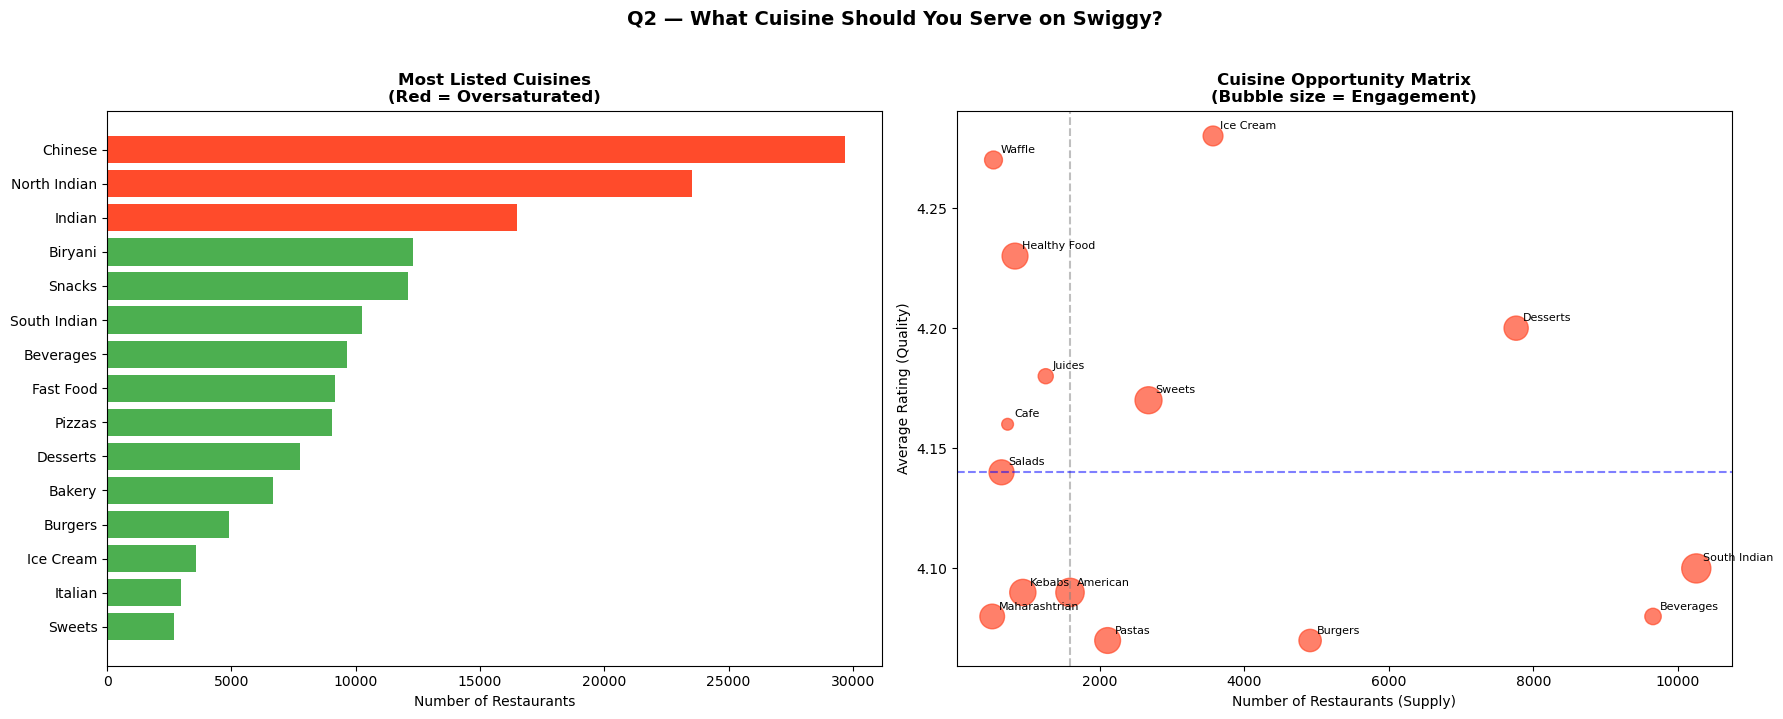

Chart saved! ✅


In [79]:
# ─────────────────────────────────────────
# Q2 — CHART: Cuisine Opportunity Matrix
# Bubble chart — Count vs Rating vs Engagement
# ─────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1 — Top 15 most listed cuisines
top_listed = cuisine_counts.head(15)
colors = ['#FF4B2B' if c in ['Chinese', 'North Indian', 'Indian'] 
          else '#4CAF50' for c in top_listed['Cuisine']]

ax1.barh(top_listed['Cuisine'], top_listed['Count'], color=colors)
ax1.set_xlabel('Number of Restaurants')
ax1.set_title('Most Listed Cuisines\n(Red = Oversaturated)', 
              fontweight='bold')
ax1.invert_yaxis()

# Chart 2 — Highest rated cuisines bubble chart
top_rated = cuisine_analysis.head(15)
scatter = ax2.scatter(top_rated['Count'], 
                      top_rated['Avg_Rating'],
                      s=top_rated['Avg_Engagement']*0.5,
                      alpha=0.7,
                      color='#FF4B2B')

for idx, row in top_rated.iterrows():
    ax2.annotate(row['Cuisine'],
                (row['Count'], row['Avg_Rating']),
                textcoords='offset points',
                xytext=(5, 5),
                fontsize=8)

ax2.set_xlabel('Number of Restaurants (Supply)')
ax2.set_ylabel('Average Rating (Quality)')
ax2.set_title('Cuisine Opportunity Matrix\n(Bubble size = Engagement)', 
              fontweight='bold')

# Add reference lines
ax2.axvline(x=top_rated['Count'].median(), 
            color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=top_rated['Avg_Rating'].median(), 
            color='blue', linestyle='--', alpha=0.5)

plt.suptitle('Q2 — What Cuisine Should You Serve on Swiggy?', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/Q2_cuisine_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved! ✅")

In [80]:
# ─────────────────────────────────────────
# Q3 — HOW SHOULD YOU PRICE?
# Which price segment performs best?
# ─────────────────────────────────────────

price_analysis = df_rated.groupby('Price Segment').agg(
    Total_Restaurants=('Restaurant Name', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Engagement=('Number of Ratings', 'mean'),
    Avg_Success_Score=('Success Score', 'mean')
).round(2).reset_index()

# Remove Unknown
price_analysis = price_analysis[price_analysis['Price Segment'] != 'Unknown']

print("Price Segment Performance:")
print(price_analysis.to_string())

Price Segment Performance:
  Price Segment  Total_Restaurants  Avg_Rating  Avg_Engagement  Avg_Success_Score
0        Budget              48600        4.02          444.07              61.47
1     Mid-Range              49436        4.04          639.14              62.32
2       Premium               7499        4.12          641.82              63.09
3        Luxury               1403        4.16          491.41              63.00


In [81]:
#Q3 FINDING:
#Mid-Range (₹200–₹400) is the optimal price point —
#highest restaurant count (49,436), strong engagement
#(639), and solid rating (4.04). Premium rates slightly
#higher (4.12) but has 6× fewer restaurants indicating
#lower overall demand on the platform.

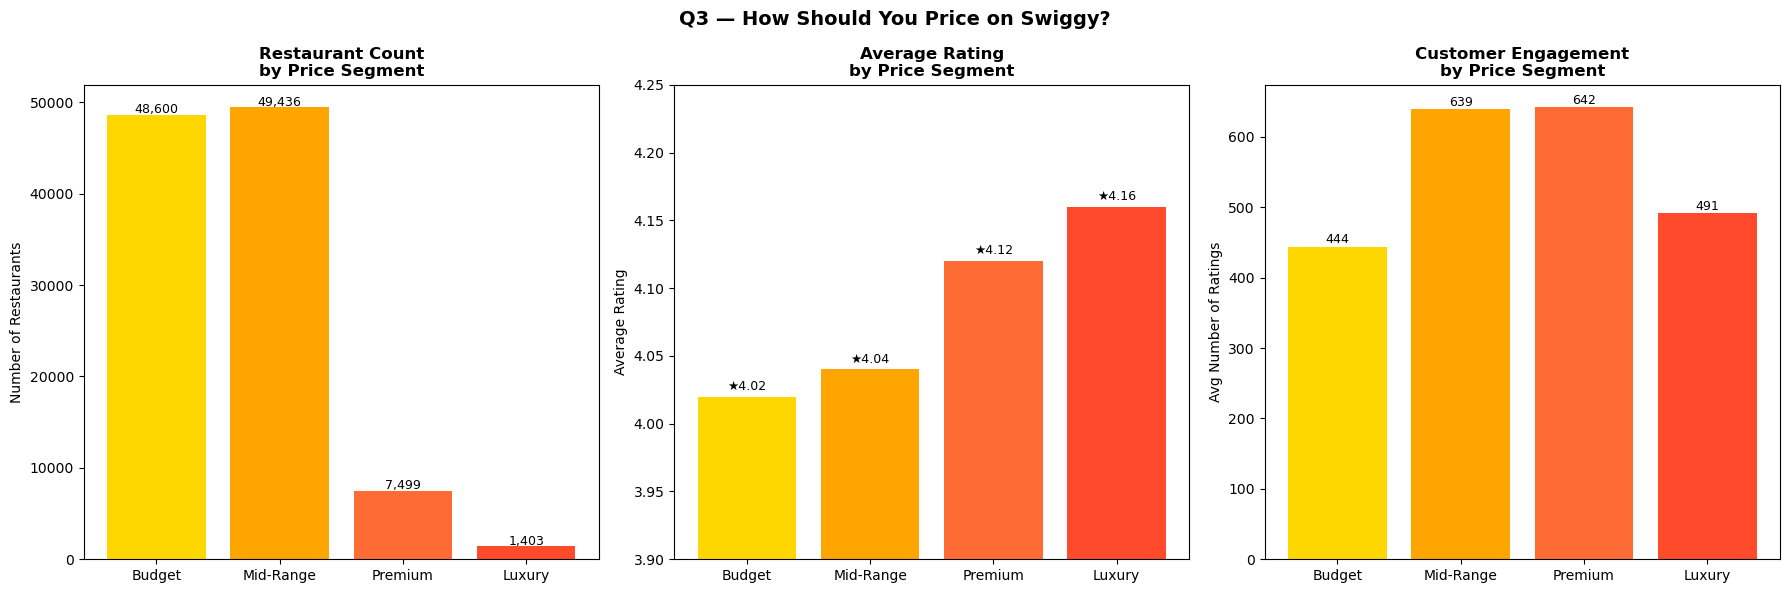

Chart saved! ✅


In [82]:
# ─────────────────────────────────────────
# Q3 — CHART: Price Segment Performance
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

segments = price_analysis['Price Segment']
colors = ['#FFD700', '#FFA500', '#FF6B35', '#FF4B2B']

# Chart 1 — Restaurant count by segment
axes[0].bar(segments, price_analysis['Total_Restaurants'], color=colors)
axes[0].set_title('Restaurant Count\nby Price Segment', fontweight='bold')
axes[0].set_ylabel('Number of Restaurants')
for i, v in enumerate(price_analysis['Total_Restaurants']):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Chart 2 — Avg rating by segment
axes[1].bar(segments, price_analysis['Avg_Rating'], color=colors)
axes[1].set_title('Average Rating\nby Price Segment', fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.9, 4.25)
for i, v in enumerate(price_analysis['Avg_Rating']):
    axes[1].text(i, v + 0.005, f'★{v}', ha='center', fontsize=9)

# Chart 3 — Engagement by segment
axes[2].bar(segments, price_analysis['Avg_Engagement'], color=colors)
axes[2].set_title('Customer Engagement\nby Price Segment', fontweight='bold')
axes[2].set_ylabel('Avg Number of Ratings')
for i, v in enumerate(price_analysis['Avg_Engagement']):
    axes[2].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)

plt.suptitle('Q3 — How Should You Price on Swiggy?', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Q3_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved! ✅")

In [83]:
# ─────────────────────────────────────────
# Q4 — SHOULD A RESTAURANT RUN OFFERS?
# Does offer intensity impact rating & engagement?
# ─────────────────────────────────────────

offer_analysis = df_rated.groupby('Offer Tier').agg(
    Total_Restaurants=('Restaurant Name', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Engagement=('Number of Ratings', 'mean'),
    Avg_Success_Score=('Success Score', 'mean')
).round(2).reset_index()

print("Offer Tier Performance:")
print(offer_analysis.to_string())

Offer Tier Performance:
  Offer Tier  Total_Restaurants  Avg_Rating  Avg_Engagement  Avg_Success_Score
0   No Offer               1187        4.01          424.85              61.33
1      Light              23454        4.06          433.24              61.87
2   Moderate              19600        4.02          651.29              62.17
3      Heavy              62697        4.03          562.23              62.01


In [84]:
#Q4 FINDING:
#Moderate offer intensity (2-3 active offers) drives 
#peak customer engagement at 651 avg ratings — 53% 
#higher than no-offer restaurants (424). However, 
#heavy discounting (4+ offers) shows diminishing 
#returns with lower engagement (562) than moderate. 
#Light offers (1) achieve the best avg rating (4.06).
#Recommendation: 2-3 strategically chosen offers 
#is the optimal strategy — not maximum discounting.

C:\Users\Druthi D\AppData\Local\Temp\ipykernel_22624\3147388574.py:38: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  plt.tight_layout()
C:\Users\Druthi D\AppData\Local\Temp\ipykernel_22624\3147388574.py:39: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  plt.savefig('outputs/Q4_offer_roi_analysis.png', dpi=150, bbox_inches='tight')
C:\Users\Druthi D\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


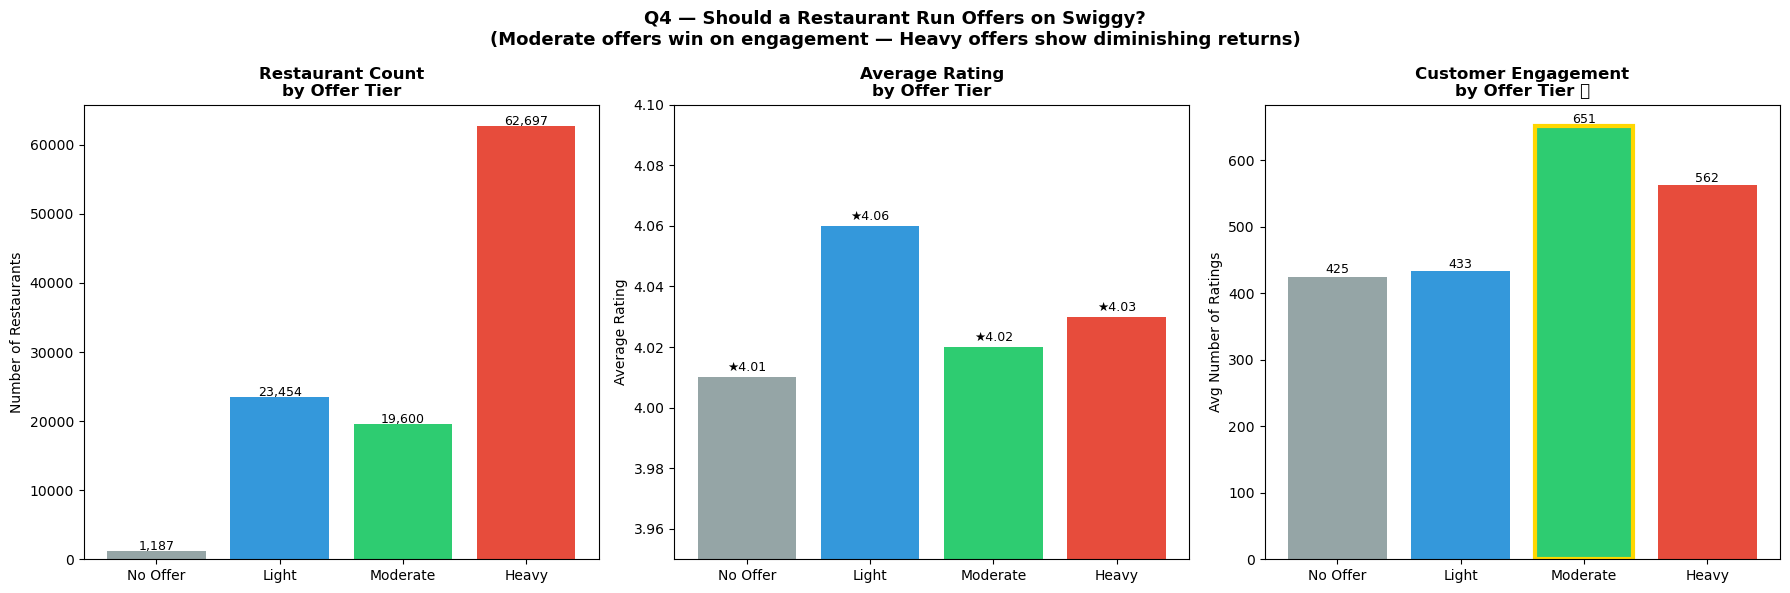

Chart saved! ✅


In [85]:
# ─────────────────────────────────────────
# Q4 — CHART: Offer ROI Analysis
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

tiers = offer_analysis['Offer Tier']
colors = ['#95A5A6', '#3498DB', '#2ECC71', '#E74C3C']

# Chart 1 — Restaurant count by offer tier
axes[0].bar(tiers, offer_analysis['Total_Restaurants'], color=colors)
axes[0].set_title('Restaurant Count\nby Offer Tier', fontweight='bold')
axes[0].set_ylabel('Number of Restaurants')
for i, v in enumerate(offer_analysis['Total_Restaurants']):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# Chart 2 — Avg rating by offer tier
axes[1].bar(tiers, offer_analysis['Avg_Rating'], color=colors)
axes[1].set_title('Average Rating\nby Offer Tier', fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(3.95, 4.10)
for i, v in enumerate(offer_analysis['Avg_Rating']):
    axes[1].text(i, v + 0.002, f'★{v}', ha='center', fontsize=9)

# Chart 3 — Engagement by offer tier (THE KEY CHART)
bars = axes[2].bar(tiers, offer_analysis['Avg_Engagement'], color=colors)
axes[2].set_title('Customer Engagement\nby Offer Tier ⭐', fontweight='bold')
axes[2].set_ylabel('Avg Number of Ratings')
for i, v in enumerate(offer_analysis['Avg_Engagement']):
    axes[2].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)

# Highlight the moderate bar
bars[2].set_edgecolor('gold')
bars[2].set_linewidth(3)

plt.suptitle('Q4 — Should a Restaurant Run Offers on Swiggy?\n(Moderate offers win on engagement — Heavy offers show diminishing returns)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Q4_offer_roi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved! ✅")

In [86]:
# ─────────────────────────────────────────
# Q5 — SHOULD A RESTAURANT GO PURE VEG?
# Does pure veg positioning affect rating & engagement?
# ─────────────────────────────────────────

pureveg_analysis = df_rated.groupby('Pure Veg').agg(
    Total_Restaurants=('Restaurant Name', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Engagement=('Number of Ratings', 'mean'),
    Avg_Success_Score=('Success Score', 'mean')
).round(2).reset_index()

print("Pure Veg vs Non-Veg Performance:")
print(pureveg_analysis.to_string())

Pure Veg vs Non-Veg Performance:
  Pure Veg  Total_Restaurants  Avg_Rating  Avg_Engagement  Avg_Success_Score
0       No              62801        4.02          598.97              62.01
1      Yes              44137        4.06          477.26              61.98


In [88]:
# ─────────────────────────────────────────
# Q5 DEEPER — Pure Veg performance by city
# Top 10 cities by restaurant count
# ─────────────────────────────────────────

# Get top 10 cities
top_10_cities = df_rated['Location'].value_counts().head(10).index.tolist()

# Filter for top 10 cities
city_veg = df_rated[df_rated['Location'].isin(top_10_cities)]

# Group by city and pure veg
city_veg_analysis = city_veg.groupby(['Location', 'Pure Veg']).agg(
    Total_Restaurants=('Restaurant Name', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Engagement=('Number of Ratings', 'mean')
).round(2).reset_index()

print("Pure Veg vs Non-Veg by City:")
print(city_veg_analysis.to_string())

Pure Veg vs Non-Veg by City:
       Location Pure Veg  Total_Restaurants  Avg_Rating  Avg_Engagement
0   Central-Goa       No               1386        4.14          348.85
1   Central-Goa      Yes                195        4.15          440.86
2    Coimbatore       No               1164        4.14          886.55
3    Coimbatore      Yes                325        4.32          853.52
4     Hyderabad       No               1160        3.96          977.60
5     Hyderabad      Yes                355        4.07         1067.49
6   Kanchrapara       No               1351        3.93          672.65
7   Kanchrapara      Yes                256        4.13          681.23
8        Kanpur       No                605        4.02          712.21
9        Kanpur      Yes               1001        4.07          551.04
10      Kolkata       No               1166        3.94          643.47
11      Kolkata      Yes                312        4.02          837.00
12      Lucknow       No           

Q5 FINDING:
Pure veg restaurants rate higher than non-veg in 
9 out of 10 top cities. Hyderabad stands out — 
pure veg gets both better rating (4.07 vs 3.96) 
AND higher engagement (1,067 vs 977) than non-veg,
making it the strongest pure veg opportunity city.
Vizag pure veg leads all cities in engagement (1,113).
Exception: Lucknow strongly favours non-veg cuisine
culturally (1,082 engagement vs 614 for pure veg).

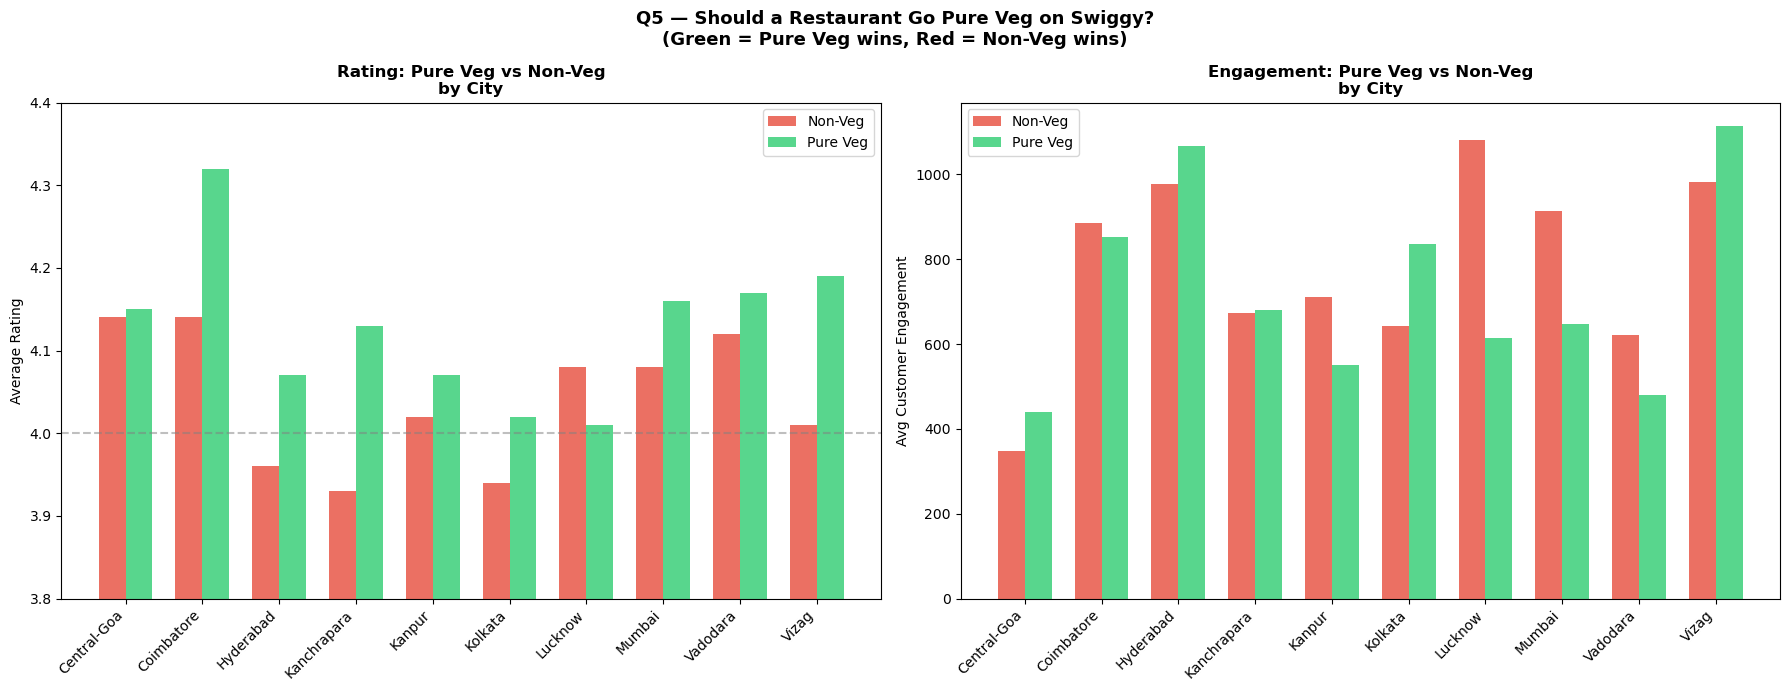

Chart saved! ✅


In [89]:
# ─────────────────────────────────────────
# Q5 — CHART: Pure Veg vs Non-Veg by City
# ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Separate veg and non-veg
veg = city_veg_analysis[city_veg_analysis['Pure Veg'] == 'Yes']
nonveg = city_veg_analysis[city_veg_analysis['Pure Veg'] == 'No']

cities = veg['Location'].tolist()
x = range(len(cities))
width = 0.35

# Chart 1 — Rating comparison
axes[0].bar([i - width/2 for i in x], nonveg['Avg_Rating'], 
            width, label='Non-Veg', color='#E74C3C', alpha=0.8)
axes[0].bar([i + width/2 for i in x], veg['Avg_Rating'], 
            width, label='Pure Veg', color='#2ECC71', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cities, rotation=45, ha='right')
axes[0].set_ylabel('Average Rating')
axes[0].set_ylim(3.8, 4.4)
axes[0].set_title('Rating: Pure Veg vs Non-Veg\nby City', fontweight='bold')
axes[0].legend()
axes[0].axhline(y=4.0, color='gray', linestyle='--', alpha=0.5)

# Chart 2 — Engagement comparison
axes[1].bar([i - width/2 for i in x], nonveg['Avg_Engagement'], 
            width, label='Non-Veg', color='#E74C3C', alpha=0.8)
axes[1].bar([i + width/2 for i in x], veg['Avg_Engagement'], 
            width, label='Pure Veg', color='#2ECC71', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cities, rotation=45, ha='right')
axes[1].set_ylabel('Avg Customer Engagement')
axes[1].set_title('Engagement: Pure Veg vs Non-Veg\nby City', fontweight='bold')
axes[1].legend()

plt.suptitle('Q5 — Should a Restaurant Go Pure Veg on Swiggy?\n(Green = Pure Veg wins, Red = Non-Veg wins)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Q5_pureveg_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved! ✅")

In [91]:
# ─────────────────────────────────────────
# Q6 — WHAT DOES A TOP RATED RESTAURANT LOOK LIKE?
# Profile the top 10% restaurants by Success Score
# ─────────────────────────────────────────

# Get top 10% success score threshold
top_10_threshold = df_rated['Success Score'].quantile(0.90)
print(f"Top 10% Success Score threshold: {top_10_threshold:.2f}")

# Filter top 10% restaurants
top_restaurants = df_rated[df_rated['Success Score'] >= top_10_threshold].copy()
print(f"Total top restaurants: {len(top_restaurants)}")

# Profile them
print("\n--- PRICE SEGMENT ---")
print(top_restaurants['Price Segment'].value_counts())

print("\n--- PURE VEG ---")
print(top_restaurants['Pure Veg'].value_counts())

print("\n--- OFFER TIER ---")
print(top_restaurants['Offer Tier'].value_counts())

print("\n--- TOP 10 CITIES ---")
print(top_restaurants['Location'].value_counts().head(10))

print("\n--- TOP 10 CUISINES ---")
cuisine_top = top_restaurants['Cuisine'].str.split(',').explode().str.strip()
print(cuisine_top.value_counts().head(10))

Top 10% Success Score threshold: 67.97
Total top restaurants: 10801

--- PRICE SEGMENT ---
Price Segment
Mid-Range    5109
Budget       4815
Premium       756
Luxury        121
Unknown         0
Name: count, dtype: int64

--- PURE VEG ---
Pure Veg
No     5978
Yes    4823
Name: count, dtype: int64

--- OFFER TIER ---
Offer Tier
Heavy       6252
Light       2327
Moderate    2085
No Offer     137
Name: count, dtype: int64

--- TOP 10 CITIES ---
Location
Bangalore     257
Coimbatore    249
Lucknow       240
Kochi         239
Delhi         236
Hyderabad     227
Kanpur        226
Vizag         221
Mumbai        206
Surat         198
Name: count, dtype: int64

--- TOP 10 CUISINES ---
Cuisine
Chinese         3024
North Indian    2427
Biryani         1333
South Indian    1322
Indian          1315
Desserts        1162
Snacks          1004
Beverages        927
Fast Food        741
Pizzas           668
Name: count, dtype: int64


Q6 FINDING:
A typical top 10% Swiggy restaurant (Success Score 
above 67.97) is Mid-Range or Budget priced (92%),
runs heavy offers (58%), and is most likely located
in Bangalore. Biryani over-indexes in top performers
(3rd in top 10% vs 4th overall) suggesting strong
quality execution in this cuisine. Premium and Luxury
restaurants make up only 8% of top performers —
confirming price alone doesn't drive success on Swiggy.

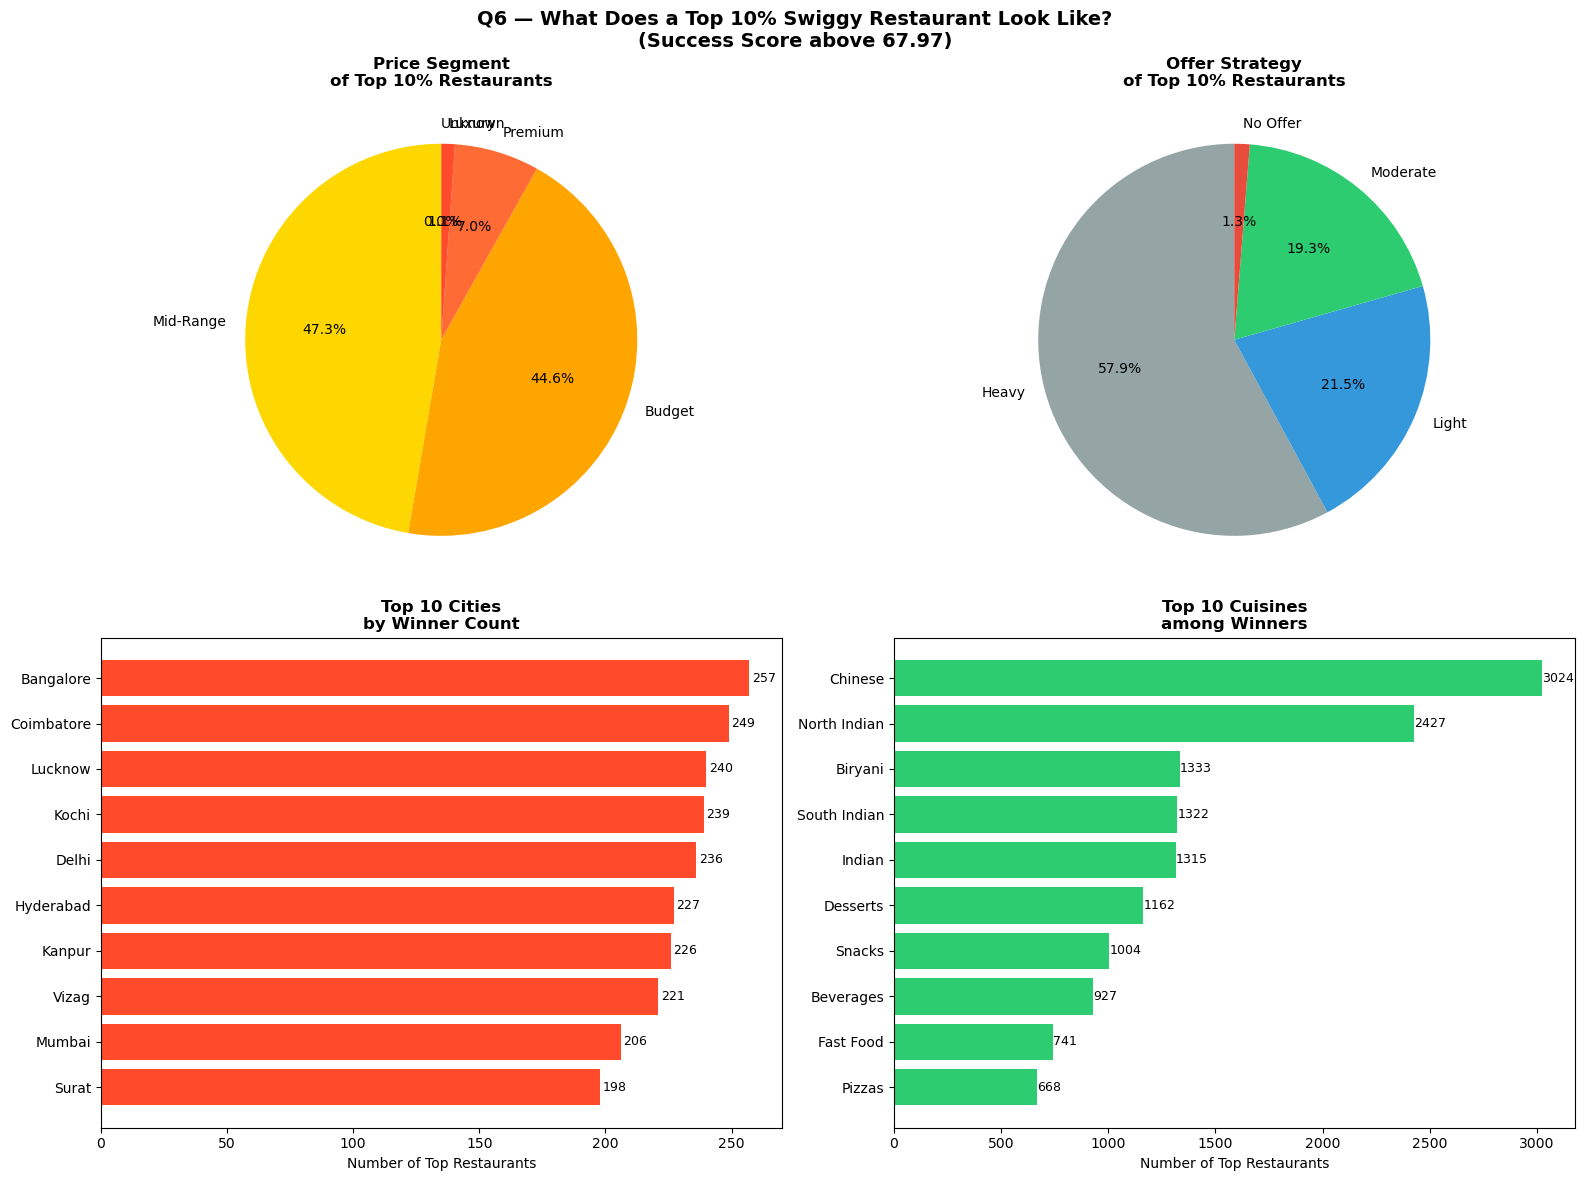

Chart saved! ✅


In [92]:
# ─────────────────────────────────────────
# Q6 — CHART: Top Restaurant Profile
# ─────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1 — Price Segment
price_top = top_restaurants['Price Segment'].value_counts()
axes[0,0].pie(price_top.values, 
              labels=price_top.index,
              autopct='%1.1f%%',
              colors=['#FFD700','#FFA500','#FF6B35','#FF4B2B','gray'],
              startangle=90)
axes[0,0].set_title('Price Segment\nof Top 10% Restaurants', 
                     fontweight='bold')

# Chart 2 — Offer Tier
offer_top = top_restaurants['Offer Tier'].value_counts()
axes[0,1].pie(offer_top.values,
              labels=offer_top.index,
              autopct='%1.1f%%',
              colors=['#95A5A6','#3498DB','#2ECC71','#E74C3C'],
              startangle=90)
axes[0,1].set_title('Offer Strategy\nof Top 10% Restaurants',
                     fontweight='bold')

# Chart 3 — Top 10 Cities
top_cities = top_restaurants['Location'].value_counts().head(10)
axes[1,0].barh(top_cities.index, top_cities.values, color='#FF4B2B')
axes[1,0].set_title('Top 10 Cities\nby Winner Count', fontweight='bold')
axes[1,0].set_xlabel('Number of Top Restaurants')
axes[1,0].invert_yaxis()
for i, v in enumerate(top_cities.values):
    axes[1,0].text(v + 1, i, str(v), va='center', fontsize=9)

# Chart 4 — Top 10 Cuisines
top_cuisines = cuisine_top.value_counts().head(10)
axes[1,1].barh(top_cuisines.index, top_cuisines.values, color='#2ECC71')
axes[1,1].set_title('Top 10 Cuisines\namong Winners', fontweight='bold')
axes[1,1].set_xlabel('Number of Top Restaurants')
axes[1,1].invert_yaxis()
for i, v in enumerate(top_cuisines.values):
    axes[1,1].text(v + 1, i, str(v), va='center', fontsize=9)

plt.suptitle('Q6 — What Does a Top 10% Swiggy Restaurant Look Like?\n(Success Score above 67.97)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/Q6_top_restaurant_profile.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved! ✅")

In [93]:
# ─────────────────────────────────────────
# SECTION 3 SUMMARY — ALL 6 FINDINGS
# ─────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════╗
║     SWIGGY RESTAURANT SUCCESS INTELLIGENCE 2024      ║
║              KEY FINDINGS SUMMARY                    ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  Q1 — WHERE TO LAUNCH?                               ║
║  Hyderabad — highest engagement (998 avg ratings)    ║
║  but below median quality (3.98) = high opportunity  ║
║                                                      ║
║  Q2 — WHAT CUISINE?                                  ║
║  Healthy Food — 4.23 rating, 694 engagement,         ║
║  only 825 restaurants vs Chinese at 29,677           ║
║                                                      ║
║  Q3 — HOW TO PRICE?                                  ║
║  Mid-Range ₹200-400 — highest count (49,436),        ║
║  strong engagement (639), solid rating (4.04)        ║
║                                                      ║
║  Q4 — RUN OFFERS?                                    ║
║  Moderate (2-3 offers) drives peak engagement        ║
║  (651) — 53% higher than no-offer restaurants        ║
║                                                      ║
║  Q5 — GO PURE VEG?                                   ║
║  Pure veg wins rating in 9/10 cities.                ║
║  Hyderabad pure veg: 4.07 rating, 1,067 engagement   ║
║                                                      ║
║  Q6 — TOP RESTAURANT PROFILE?                        ║
║  Mid-Range/Budget (92%), Heavy offers (58%),         ║
║  Bangalore leads with most top performers (257)      ║
║                                                      ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║     SWIGGY RESTAURANT SUCCESS INTELLIGENCE 2024      ║
║              KEY FINDINGS SUMMARY                    ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  Q1 — WHERE TO LAUNCH?                               ║
║  Hyderabad — highest engagement (998 avg ratings)    ║
║  but below median quality (3.98) = high opportunity  ║
║                                                      ║
║  Q2 — WHAT CUISINE?                                  ║
║  Healthy Food — 4.23 rating, 694 engagement,         ║
║  only 825 restaurants vs Chinese at 29,677           ║
║                                                      ║
║  Q3 — HOW TO PRICE?                                  ║
║  Mid-Range ₹200-400 — highest count (49,436),        ║
║  strong engagement (639), solid rating (4.04)        ║
║                                                      ║
║  Q4 — RUN OFFERS?           

In [97]:
# ============================================
# SECTION 4 — SQL ANALYSIS USING SQLITE
# ============================================

import sqlite3
import pandas as pd

# Create SQLite database
conn = sqlite3.connect('swiggy.db')

# Load cleaned data into SQLite table
df_rated.to_sql('restaurants', conn, 
                if_exists='replace', 
                index=False)

print("✅ Database created successfully!")
print(f"✅ Table loaded with {len(df_rated)} rows")

# Helper function to run queries easily
def run_query(query):
    return pd.read_sql_query(query, conn)

✅ Database created successfully!
✅ Table loaded with 106938 rows


In [98]:
# ─────────────────────────────────────────
# SQL Q1 — Top 10 cities by average rating
# ─────────────────────────────────────────

result1 = run_query("""
    SELECT Location,
           ROUND(AVG(Rating), 2) AS Avg_Rating,
           COUNT(*) AS Total_Restaurants,
           ROUND(AVG("Number of Ratings"), 0) AS Avg_Engagement
    FROM restaurants
    GROUP BY Location
    HAVING COUNT(*) > 200
    ORDER BY Avg_Rating DESC
    LIMIT 10
""")

print("SQL Q1 — Top 10 Cities by Average Rating:")
print(result1.to_string())

SQL Q1 — Top 10 Cities by Average Rating:
             Location  Avg_Rating  Total_Restaurants  Avg_Engagement
0             Manipal        4.27                217          1261.0
1              Rajkot        4.26                771           595.0
2               Kochi        4.26               1184          1043.0
3            Palakkad        4.25                305           652.0
4           Mangaluru        4.25                644           933.0
5             Bantwal        4.25                640           931.0
6  Thiruvananthapuram        4.24                748          1301.0
7               Anand        4.24                222           285.0
8         Tirunelveli        4.22                238           480.0
9            Thrissur        4.22                460          1014.0


In [99]:
# ─────────────────────────────────────────
# SQL Q2 — Offer impact on rating & engagement
# ─────────────────────────────────────────

result2 = run_query("""
    SELECT "Offer Tier",
           COUNT(*) AS Total_Restaurants,
           ROUND(AVG(Rating), 2) AS Avg_Rating,
           ROUND(AVG("Number of Ratings"), 0) AS Avg_Engagement,
           ROUND(AVG("Success Score"), 2) AS Avg_Success_Score
    FROM restaurants
    GROUP BY "Offer Tier"
    ORDER BY Avg_Engagement DESC
""")

print("SQL Q2 — Offer Tier Impact on Performance:")
print(result2.to_string())

SQL Q2 — Offer Tier Impact on Performance:
  Offer Tier  Total_Restaurants  Avg_Rating  Avg_Engagement  Avg_Success_Score
0   Moderate              19600        4.02           651.0              62.17
1      Heavy              62697        4.03           562.0              62.01
2      Light              23454        4.06           433.0              61.87
3   No Offer               1187        4.01           425.0              61.33


In [100]:
# ─────────────────────────────────────────
# SQL Q3 — Best cuisine by average rating
# ─────────────────────────────────────────

result3 = run_query("""
    SELECT Cuisine,
           COUNT(*) AS Total_Restaurants,
           ROUND(AVG(Rating), 2) AS Avg_Rating,
           ROUND(AVG("Number of Ratings"), 0) AS Avg_Engagement
    FROM restaurants
    WHERE Cuisine != 'Unknown'
    GROUP BY Cuisine
    HAVING COUNT(*) > 500
    ORDER BY Avg_Rating DESC
    LIMIT 10
""")

print("SQL Q3 — Top 10 Cuisines by Average Rating:")
print(result3.to_string())

SQL Q3 — Top 10 Cuisines by Average Rating:
                      Cuisine  Total_Restaurants  Avg_Rating  Avg_Engagement
0         Ice Cream, Desserts                950        4.44           539.0
1         Desserts, Ice Cream                650        4.39           432.0
2                   Ice Cream                518        4.27           330.0
3           Desserts, Chinese                528        4.21          1777.0
4              Sweets, Snacks                575        4.20           632.0
5  South Indian, North Indian                775        4.17          1740.0
6                    Desserts                722        4.17           470.0
7       South Indian, Biryani                522        4.14           813.0
8                South Indian               2245        4.11           700.0
9       South Indian, Chinese               1248        4.10           928.0


In [101]:
# ─────────────────────────────────────────
# SQL Q4 — Price segment performance
# ─────────────────────────────────────────

result4 = run_query("""
    SELECT "Price Segment",
           COUNT(*) AS Total_Restaurants,
           ROUND(AVG(Rating), 2) AS Avg_Rating,
           ROUND(AVG("Number of Ratings"), 0) AS Avg_Engagement,
           ROUND(AVG("Average Price"), 0) AS Avg_Price,
           ROUND(AVG("Success Score"), 2) AS Avg_Success_Score
    FROM restaurants
    WHERE "Price Segment" != 'Unknown'
    GROUP BY "Price Segment"
    ORDER BY Avg_Rating DESC
""")

print("SQL Q4 — Price Segment Performance:")
print(result4.to_string())

SQL Q4 — Price Segment Performance:
  Price Segment  Total_Restaurants  Avg_Rating  Avg_Engagement  Avg_Price  Avg_Success_Score
0        Luxury               1403        4.16           491.0      998.0              63.00
1       Premium               7499        4.12           642.0      528.0              63.09
2     Mid-Range              49436        4.04           639.0      304.0              62.32
3        Budget              48600        4.02           444.0      174.0              61.47


In [102]:
# ─────────────────────────────────────────
# SQL Q5 — Pure Veg vs Non-Veg by city
# Top 10 cities only
# ─────────────────────────────────────────

result5 = run_query("""
    SELECT Location,
           "Pure Veg",
           COUNT(*) AS Total_Restaurants,
           ROUND(AVG(Rating), 2) AS Avg_Rating,
           ROUND(AVG("Number of Ratings"), 0) AS Avg_Engagement
    FROM restaurants
    WHERE Location IN (
        SELECT Location 
        FROM restaurants 
        GROUP BY Location 
        ORDER BY COUNT(*) DESC 
        LIMIT 10
    )
    GROUP BY Location, "Pure Veg"
    ORDER BY Location, "Pure Veg"
""")

print("SQL Q5 — Pure Veg vs Non-Veg by Top 10 Cities:")
print(result5.to_string())

SQL Q5 — Pure Veg vs Non-Veg by Top 10 Cities:
       Location Pure Veg  Total_Restaurants  Avg_Rating  Avg_Engagement
0   Central-Goa       No               1386        4.14           349.0
1   Central-Goa      Yes                195        4.15           441.0
2    Coimbatore       No               1164        4.14           887.0
3    Coimbatore      Yes                325        4.32           854.0
4     Hyderabad       No               1160        3.96           978.0
5     Hyderabad      Yes                355        4.07          1067.0
6   Kanchrapara       No               1351        3.93           673.0
7   Kanchrapara      Yes                256        4.13           681.0
8        Kanpur       No                605        4.02           712.0
9        Kanpur      Yes               1001        4.07           551.0
10      Kolkata       No               1166        3.94           643.0
11      Kolkata      Yes                312        4.02           837.0
12      Lucknow  

In [103]:
# Export cleaned data for Power BI
df_rated.to_csv('swiggy_powerbi.csv', index=False)
print("✅ File exported for Power BI!")
print(f"Total rows: {len(df_rated)}")

✅ File exported for Power BI!
Total rows: 106938


In [104]:
import os

# This will tell you exactly where the file was saved
print("File saved at:")
print(os.path.abspath('swiggy_powerbi.csv'))

# Also confirm it exists
if os.path.exists('swiggy_powerbi.csv'):
    print("✅ File exists!")
else:
    print("❌ File not found — let's save it again")
    df_rated.to_csv('swiggy_powerbi.csv', index=False)
    print("✅ File saved now!")
    print(os.path.abspath('swiggy_powerbi.csv'))

File saved at:
C:\Users\Druthi D\swiggy_powerbi.csv
✅ File exists!


In [105]:
df_rated = df_rated[~df_rated['Cuisine'].isin(['Yes', 'No', 'Unknown'])]
df_rated.to_csv('swiggy_powerbi.csv', index=False)
print("✅ Fixed!")

✅ Fixed!


In [106]:
df_rated = df_rated[~df_rated['Cuisine'].isin(['Yes', 'No', 'Unknown'])]
df_rated.to_csv('swiggy_powerbi.csv', index=False)
print(f"✅ Done! Rows: {len(df_rated)}")

✅ Done! Rows: 106938


In [107]:
import os

# List all CSV files in current directory
csv_files = [f for f in os.listdir('.') if f.endswith('.csv')]
print("CSV files found:")
for f in csv_files:
    print(f"  - {f}")

CSV files found:
  - customer_shopping_behavior.csv
  - overall_economy.csv
  - overall_engagement.csv
  - overall_retention.csv
  - retail_clean.csv
  - retail_full.csv
  - rules.csv
  - Spotify Dataset.csv
  - swiggy_file.csv
  - swiggy_powerbi.csv


In [108]:
import pandas as pd
import numpy as np

# Load original file
df = pd.read_csv('swiggy_file.csv', encoding='utf-8', on_bad_lines='skip')

print(f"Original shape: {df.shape}")

# ── All cleaning steps ──────────────────────

# Clean Rating
df['Rating'] = df['Rating'].replace({'--': np.nan, 'NEW': np.nan})
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Clean Number of Ratings
def parse_num_ratings(val):
    val = str(val).strip().upper()
    if 'TOO FEW' in val or val == 'NAN':
        return np.nan
    val = val.replace('+ RATINGS', '').replace(' RATINGS', '').strip()
    if 'K' in val:
        return float(val.replace('K', '')) * 1000
    try:
        return float(val.replace('+', ''))
    except:
        return np.nan

df['Number of Ratings'] = df['Number of Ratings'].apply(parse_num_ratings)

# Clean Average Price
df['Average Price'] = df['Average Price'].str.replace('₹', '', regex=False)
df['Average Price'] = df['Average Price'].str.replace('for two', '', regex=False)
df['Average Price'] = df['Average Price'].str.replace(',', '', regex=False).str.strip()
df['Average Price'] = pd.to_numeric(df['Average Price'], errors='coerce')

# Clean Offer Name
df['Offer Name'] = df['Offer Name'].str.replace('\n', ' | ', regex=False)
df['Offer Name'] = df['Offer Name'].fillna('No Offer')

# Fill nulls
df['Cuisine'] = df['Cuisine'].fillna('Unknown')
df['Area'] = df['Area'].fillna('Unknown')
df['Pure Veg'] = df['Pure Veg'].str.strip().str.capitalize()

# Feature Engineering
df['Price Segment'] = pd.cut(df['Average Price'],
    bins=[0, 200, 400, 700, 99999],
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury'])
df['Price Segment'] = df['Price Segment'].cat.add_categories('Unknown')
df['Price Segment'] = df['Price Segment'].fillna('Unknown')
df['Has Offer'] = df['Number of Offers'] > 0
df['Offer Tier'] = pd.cut(df['Number of Offers'],
    bins=[-1, 0, 1, 3, 100],
    labels=['No Offer', 'Light', 'Moderate', 'Heavy'])
df['Engagement Rate'] = df['Number of Ratings'] / (df['Average Price'] + 1)
df['Success Score'] = (
    (df['Rating'] / 5) * 0.5 +
    (df['Number of Ratings'] / df['Number of Ratings'].max()) * 0.3 +
    (1 - df['Average Price'] / df['Average Price'].max()) * 0.2
) * 100

# Filter rated restaurants
df_rated = df[df['Rating'].notna()].copy()

# ── Remove bad cuisine values ────────────────
df_rated = df_rated[
    ~df_rated['Cuisine'].str.contains(
        'Yes|No|Unknown|km|•',
        case=False,
        na=False
    )
]

print(f"Clean rows: {len(df_rated)}")

# Save for Power BI
df_rated.to_csv('swiggy_powerbi.csv', index=False)
print("✅ Clean file saved!")

Original shape: (140657, 10)
Clean rows: 83313
✅ Clean file saved!


In [46]:
print(df_rated['Pure Veg'].unique())
print(df_rated['Pure Veg'].value_counts())

['No' 'Yes']
Pure Veg
No     47775
Yes    35538
Name: count, dtype: int64
